# Lab 4: Model-Based Offline Optimization

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [93]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [94]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [95]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )



model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 607.6218, Val Loss: 559.9641
Epoch 20/100, Train Loss: 401.9885, Val Loss: 393.4884
Epoch 30/100, Train Loss: 311.4229, Val Loss: 307.0386
Epoch 40/100, Train Loss: 244.8887, Val Loss: 242.8743
Epoch 50/100, Train Loss: 203.0581, Val Loss: 208.0145
Epoch 60/100, Train Loss: 178.5294, Val Loss: 172.1681
Epoch 70/100, Train Loss: 164.0067, Val Loss: 158.5277
Epoch 80/100, Train Loss: 150.2845, Val Loss: 149.2516
Epoch 90/100, Train Loss: 136.9798, Val Loss: 132.5430
Epoch 100/100, Train Loss: 127.5218, Val Loss: 132.9963
Test Loss: 135.4444


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

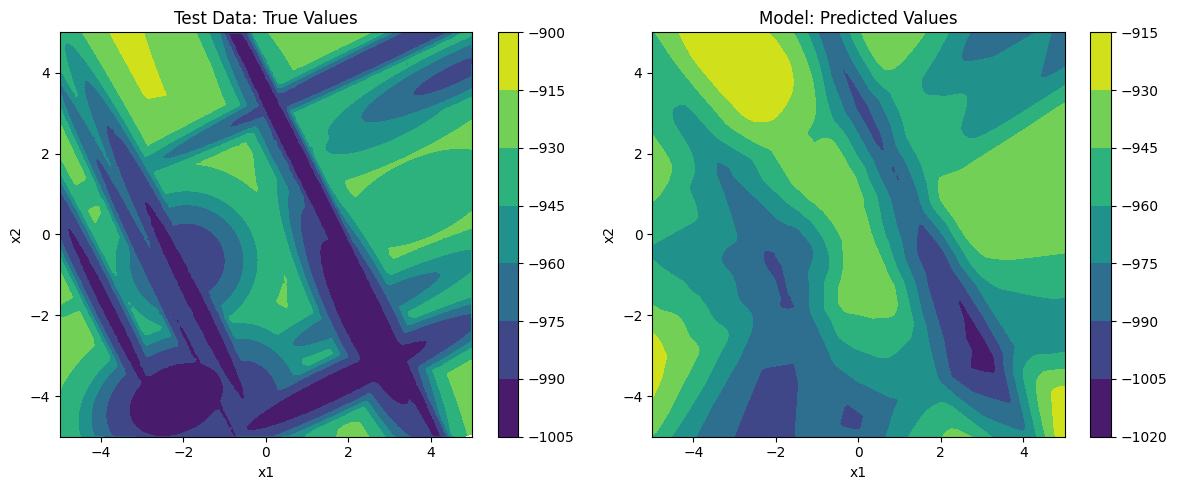

In [96]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

We can see some resemblance between the true values and model predicted values, however the resemblance is not perfectly clear

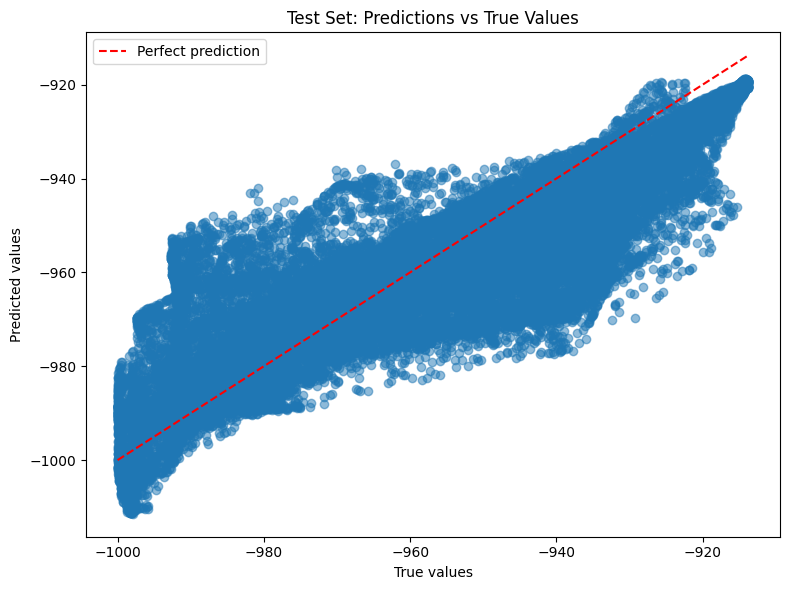

In [97]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

This scatterplot shows what was mentioned previously, there is resemblance but the model/mapping isn't perfect

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [103]:
from torch.optim import Adam
def optimize_model(
    model: nn.Module, num_steps: int = 1000, learning_rate: float = 1
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()

    # Select random starting point in [-5, 5]^2
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)

    # Use Adam optimizer for the input x
    optimizer = Adam([x], lr=learning_rate)

    best_x = None
    best_y = float('inf')

    for _ in range(num_steps):
        optimizer.zero_grad()

        # Predict output (we want to minimize this)
        y = model(x)

        # Compute gradients
        y.backward()

        # Update x
        optimizer.step()

        # Enforce domain constraints [-5, 5] using projection
        with torch.no_grad():
            x.data = torch.clamp(x.data, -5, 5)

        # Track best solution found
        current_y = y.item()
        if current_y < best_y:
            best_y = current_y
            best_x = x.detach().clone()
    return best_x, best_y

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.

# Impact of Data Size

In [24]:
from sklearn.metrics import r2_score

def train_model(train_dataloader, val_dataloader, test_dataloader, device):
    model = MLP().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_size = len(train_dataloader.dataset)

    num_epochs = 100
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        train_loss = train_loss / len(train_dataloader.dataset)
        train_losses.append(train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_dataloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss = val_loss / len(val_dataloader.dataset)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # R2 Score on Test Set
    model.eval()
    test_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    test_loss = test_loss / len(test_dataloader.dataset)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    r2 = r2_score(all_targets, all_preds)

    print(f"Train Size: {train_size}, Test MSE: {test_loss:.4f}, R² Score: {r2:.4f}")

    return model, train_size, test_loss, r2

In [30]:
def evaluation_pipeline(training_set_sizes:list[float]=[0.001, 0.01, 0.05, 0.1, 0.5], dataset_path:str='./bbob_f022_i01_d02_samples.csv'):
  train_sizes = []
  losses = []
  r2_scores = []
  for size in training_set_sizes:
    train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    dataset_path, train_perc=size
    )
    model, train_size, test_loss, r2  = train_model(train_dataloader, val_dataloader, test_dataloader, device)
    train_sizes.append(train_size)
    losses.append(test_loss)
    r2_scores.append(r2)
    plot_contour_comparison(model, test_dataloader, device)
  return train_sizes, losses, r2_scores

Epoch 10/100, Train Loss: 895413.7500, Val Loss: 905722.9254
Epoch 20/100, Train Loss: 869945.6875, Val Loss: 879531.0379
Epoch 30/100, Train Loss: 830382.5625, Val Loss: 839254.7090
Epoch 40/100, Train Loss: 773697.1875, Val Loss: 781954.7132
Epoch 50/100, Train Loss: 698048.3125, Val Loss: 705972.9759
Epoch 60/100, Train Loss: 604055.2500, Val Loss: 612072.5438
Epoch 70/100, Train Loss: 495723.2812, Val Loss: 504320.0615
Epoch 80/100, Train Loss: 381082.5625, Val Loss: 390672.1565
Epoch 90/100, Train Loss: 271866.4062, Val Loss: 282569.9326
Epoch 100/100, Train Loss: 181364.5781, Val Loss: 192828.7299
Train Size: 100, Test MSE: 194210.5659, R² Score: -318.6092


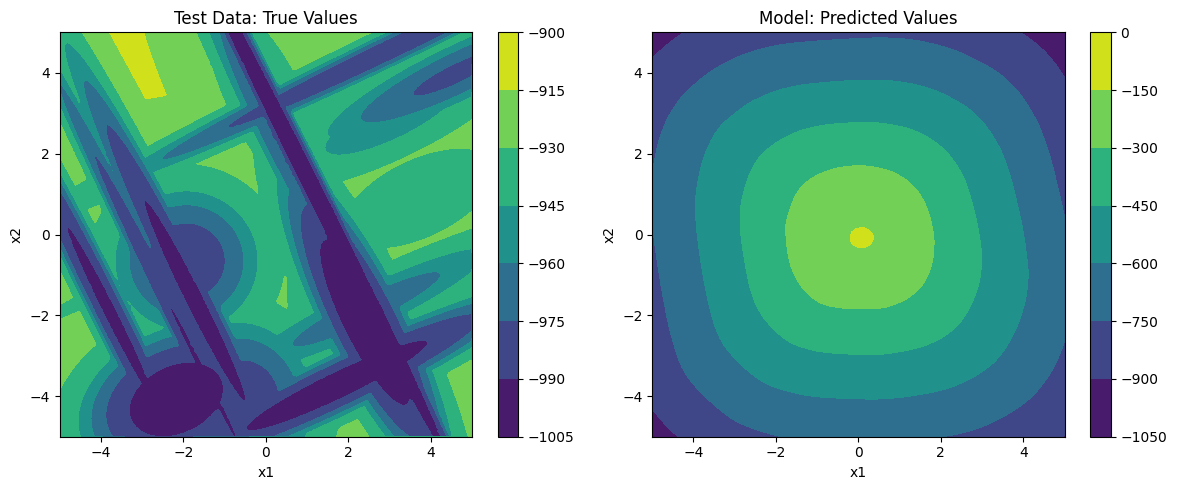

Epoch 10/100, Train Loss: 787473.2515, Val Loss: 769681.9751
Epoch 20/100, Train Loss: 394519.3745, Val Loss: 363307.4425
Epoch 30/100, Train Loss: 96946.0699, Val Loss: 91535.0060
Epoch 40/100, Train Loss: 82907.4086, Val Loss: 82341.1955
Epoch 50/100, Train Loss: 78907.9039, Val Loss: 78405.4851
Epoch 60/100, Train Loss: 74945.4664, Val Loss: 74585.1946
Epoch 70/100, Train Loss: 70783.1389, Val Loss: 70520.7535
Epoch 80/100, Train Loss: 66380.5546, Val Loss: 66252.2842
Epoch 90/100, Train Loss: 61727.5906, Val Loss: 61677.9091
Epoch 100/100, Train Loss: 56801.5177, Val Loss: 56843.1772
Train Size: 1000, Test MSE: 56641.8657, R² Score: -91.8282


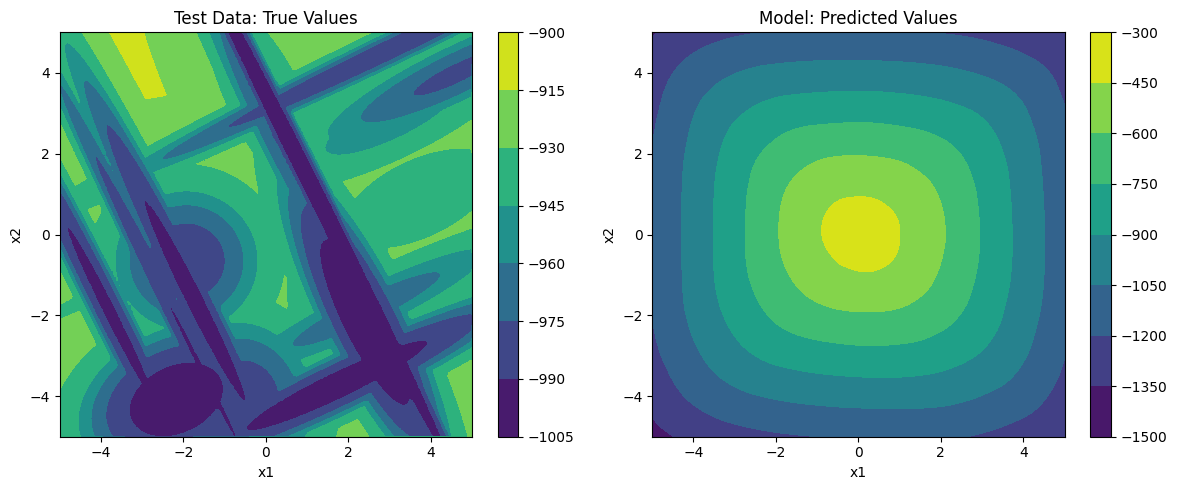

Epoch 10/100, Train Loss: 75172.4598, Val Loss: 76765.3835
Epoch 20/100, Train Loss: 54594.5802, Val Loss: 55195.8941
Epoch 30/100, Train Loss: 27487.8808, Val Loss: 26793.5491
Epoch 40/100, Train Loss: 5795.3478, Val Loss: 5352.5881
Epoch 50/100, Train Loss: 837.3297, Val Loss: 799.2590
Epoch 60/100, Train Loss: 470.8292, Val Loss: 469.7082
Epoch 70/100, Train Loss: 405.9714, Val Loss: 405.1133
Epoch 80/100, Train Loss: 376.1294, Val Loss: 375.0687
Epoch 90/100, Train Loss: 359.1033, Val Loss: 357.7495
Epoch 100/100, Train Loss: 340.8933, Val Loss: 342.9217
Train Size: 5000, Test MSE: 342.1048, R² Score: 0.4392


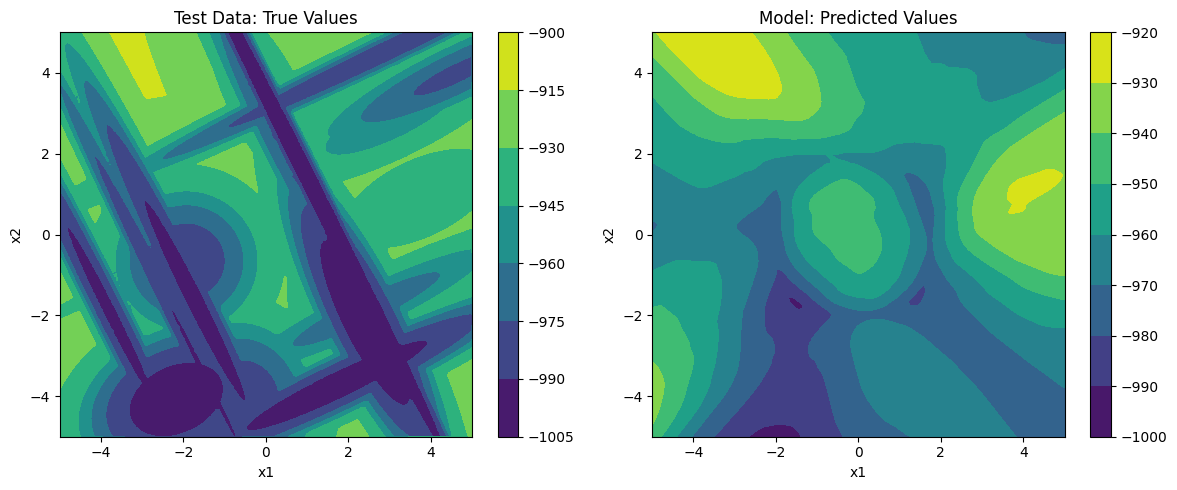

Epoch 10/100, Train Loss: 54029.2310, Val Loss: 51100.6875
Epoch 20/100, Train Loss: 6798.7753, Val Loss: 5620.4946
Epoch 30/100, Train Loss: 527.7044, Val Loss: 510.0684
Epoch 40/100, Train Loss: 417.4411, Val Loss: 409.8947
Epoch 50/100, Train Loss: 366.0070, Val Loss: 360.4936
Epoch 60/100, Train Loss: 335.9773, Val Loss: 330.3551
Epoch 70/100, Train Loss: 314.3800, Val Loss: 307.8294
Epoch 80/100, Train Loss: 296.5976, Val Loss: 292.3646
Epoch 90/100, Train Loss: 280.8101, Val Loss: 272.3565
Epoch 100/100, Train Loss: 262.4184, Val Loss: 256.3409
Train Size: 10000, Test MSE: 258.4093, R² Score: 0.5746


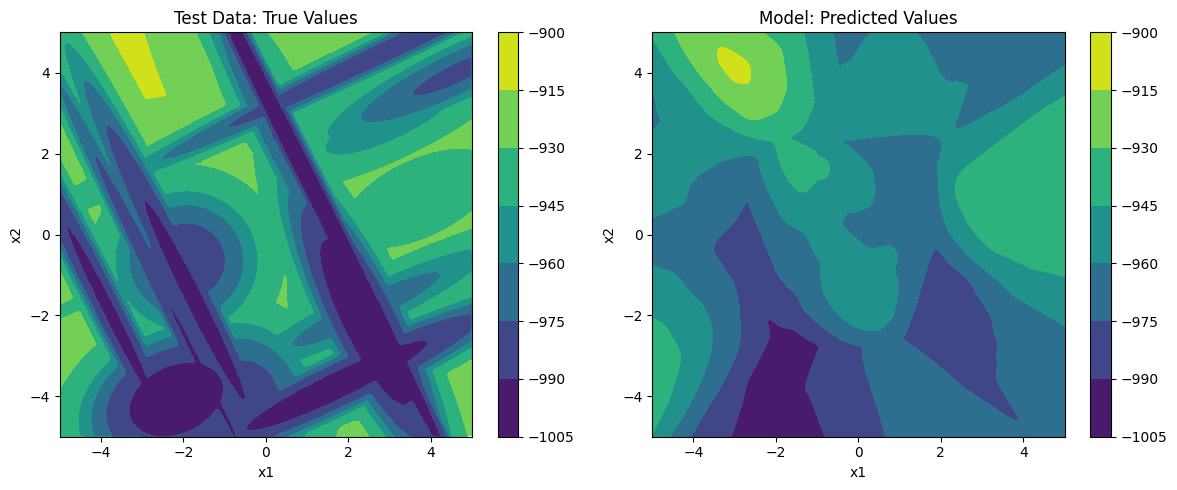

Epoch 10/100, Train Loss: 442.2674, Val Loss: 434.6948
Epoch 20/100, Train Loss: 301.8513, Val Loss: 298.4432
Epoch 30/100, Train Loss: 212.4944, Val Loss: 212.4520
Epoch 40/100, Train Loss: 168.2713, Val Loss: 175.3223
Epoch 50/100, Train Loss: 144.9245, Val Loss: 139.8017
Epoch 60/100, Train Loss: 130.2059, Val Loss: 122.8128
Epoch 70/100, Train Loss: 118.8543, Val Loss: 117.9120
Epoch 80/100, Train Loss: 110.7334, Val Loss: 118.1580
Epoch 90/100, Train Loss: 104.9070, Val Loss: 108.5414
Epoch 100/100, Train Loss: 100.7873, Val Loss: 97.1874
Train Size: 50000, Test MSE: 98.6129, R² Score: 0.8386


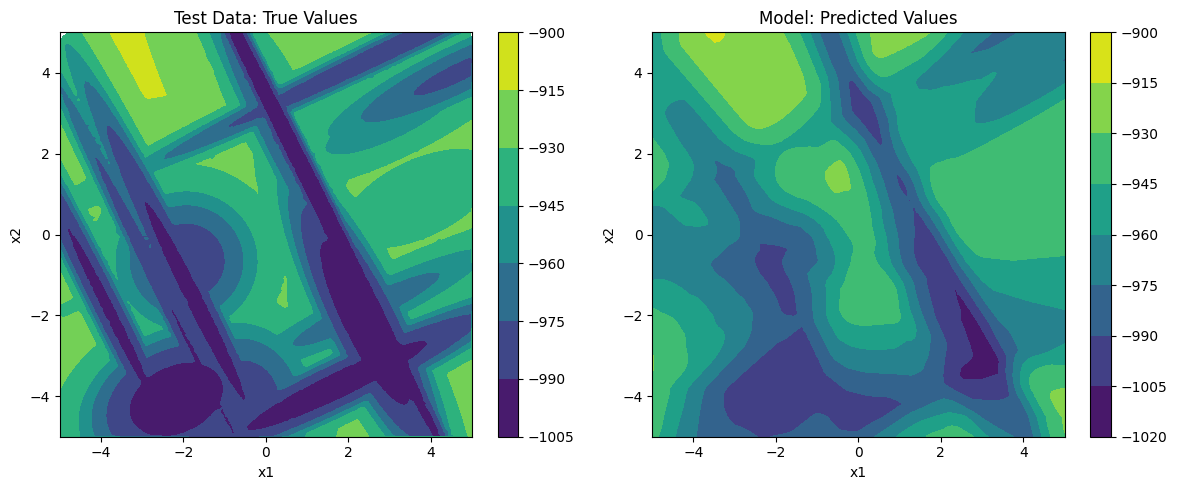

In [31]:
train_sizes, losses, r2_scores = evaluation_pipeline()

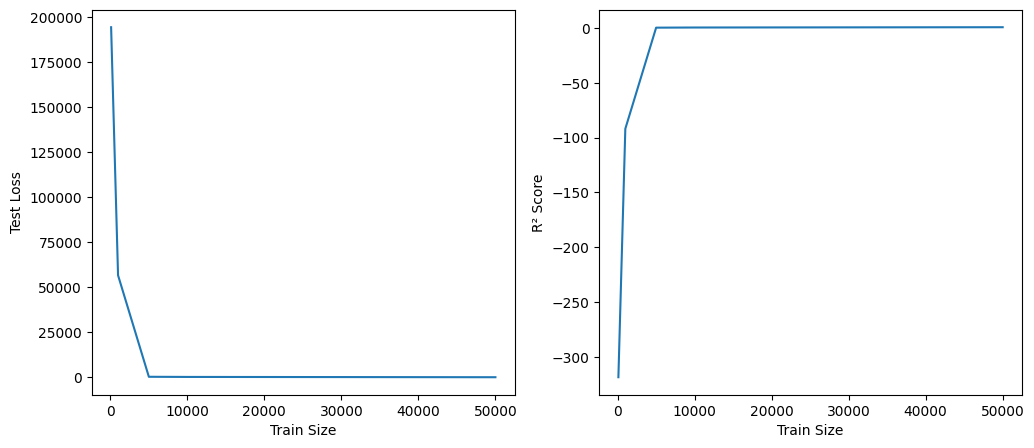

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(train_sizes,losses)
ax2.plot(train_sizes,r2_scores)
ax1.set_xlabel('Train Size')
ax1.set_ylabel('Test Loss')
ax2.set_xlabel('Train Size')
ax2.set_ylabel('R² Score')
plt.show()

Amount of data available plays significant role in the prcoess of model training. I can say that models with percentage of total data lower than 10% (10k datapoints) don't resemble the original true values when compared on the contourplot

As the quantitative method for measuring the model's predictability I used MSE and R2_score, because I thought they were generally good for measuring performance of regression problems. We can see that with the availability of data the metrics improve, especially at the beginning. The metrics improve dramatically to around 5k of examples, then the improvements are not that significant.

# Optimization Robustness

In [104]:
best_x_y = [optimize_model(model) for _ in range(10)]
best_y = [y[1] for y in best_x_y]

In [105]:
import seaborn as sns

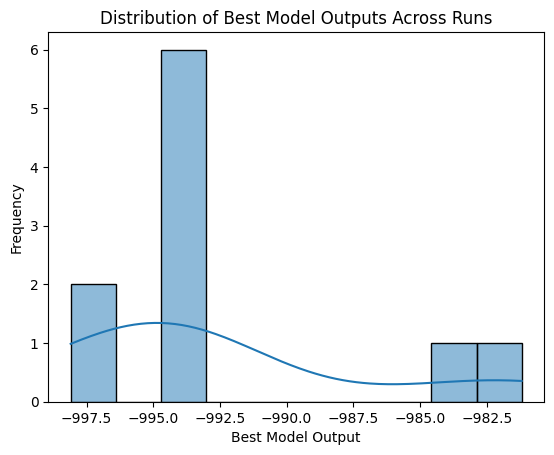

In [106]:
sns.histplot(best_y, bins=10, kde=True)
plt.xlabel("Best Model Output")
plt.ylabel("Frequency")
plt.title("Distribution of Best Model Outputs Across Runs")
plt.show()

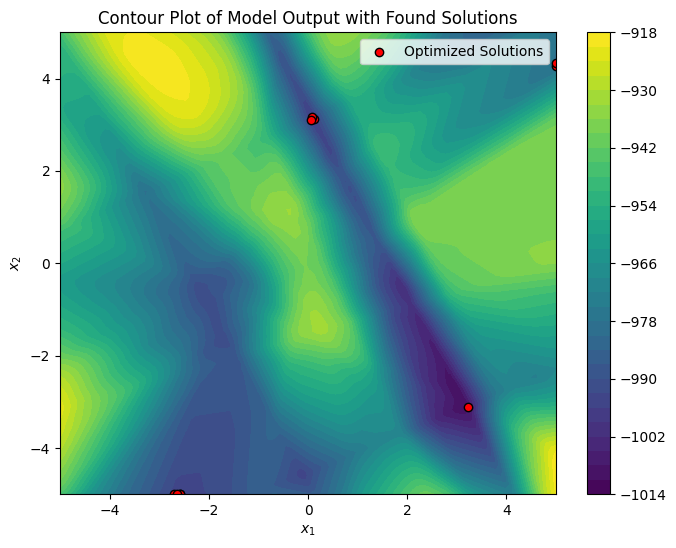

In [107]:
x1_range = np.linspace(-5, 5, 100)
x2_range = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

# Compute model predictions for the entire grid
model.eval()
with torch.no_grad():
    Z = model(grid_tensor).cpu().numpy().reshape(X1.shape)


best_x_y = []
for _ in range(10):
    best_x, best_y = optimize_model(model)
    best_x_y.append(best_x)

best_x_y = np.array(best_x_y)
best_x_y = best_x_y.reshape(10, 2)


plt.figure(figsize=(8, 6))
contour = plt.contourf(X1, X2, Z, levels=30, cmap="viridis")
plt.colorbar(contour)


plt.scatter(best_x_y[:, 0], best_x_y[:, 1], color="red", edgecolors="black", label="Optimized Solutions")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Contour Plot of Model Output with Found Solutions")
plt.legend()
plt.show()

In [108]:
best_x_y

array([[ 3.2270734 , -3.1101518 ],
       [ 0.11574793,  3.1246393 ],
       [ 5.        ,  4.2793655 ],
       [-2.581678  , -5.        ],
       [-2.5786247 , -5.        ],
       [ 0.07052039,  3.1673775 ],
       [ 0.05471957,  3.1080337 ],
       [-2.7104862 , -5.        ],
       [ 5.        ,  4.341331  ],
       [-2.6371722 , -5.        ]], dtype=float32)

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [ ]:
! pip install coco-experiment cocopp

In [112]:
from cocoex import Suite

function_id = 22  # Switch between 1 and 22 to change the function

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([3.2270734 , -3.1101518])))

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -998.0294933187661


In [111]:
function_id = 1

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

bbob_f001_i01_d02: a 2-dimensional single-objective problem (problem 0 of suite "b'bbob'" with name "BBOB suite problem f1 instance 1 in 2D")
Function value at (0, 0): 80.88209408
